✅ Libraries Loaded Successfully
✅ Dataset loaded  | Shape: (7043, 20)
   Churn Rate     : 26.5%
   Churn dtype    : int64
Churn
0    5174
1    1869
Name: count, dtype: int64
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0  Female              0        1           0       1             0   
1    Male              0        0           0      34             1   
2    Male              0        0           0       2             1   
3    Male              0        0           0      45             0   
4  Female              0        0           0       2             1   

   MultipleLines InternetService  OnlineSecurity  OnlineBackup  \
0              0             DSL               0             1   
1              0             DSL               1             0   
2              0             DSL               1             1   
3              0             DSL               1             0   
4              0     Fiber optic               0             0   

  

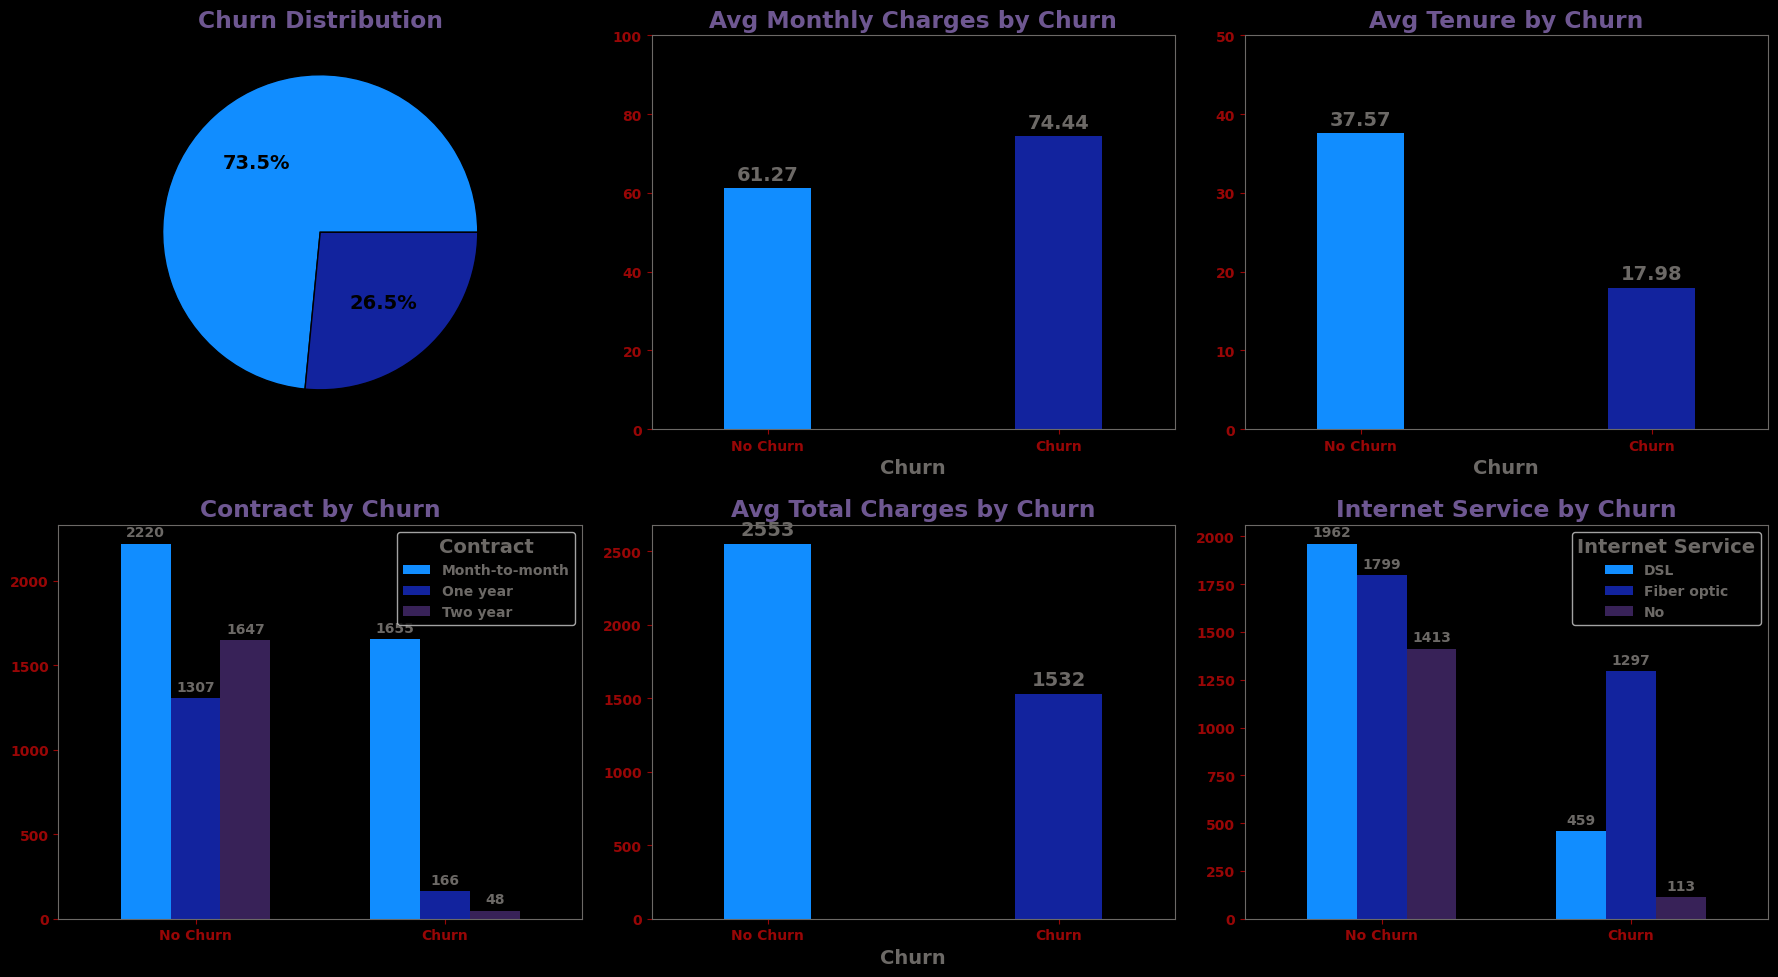

In [7]:
!pip install shap imbalanced-learn xgboost streamlit -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from collections import Counter

warnings.filterwarnings('ignore')
np.random.seed(42)

TITLE = '#6E5791'
VALUE = '#980606'
LABEL = '#6C6966'
BAR   = ['#118DFF','#12239E','#382258']

plt.rcParams.update({
    'font.size': 14, 'font.weight': 'bold',
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold',
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'figure.facecolor': '#000000', 'axes.facecolor': '#000000',
    'axes.edgecolor': LABEL, 'axes.labelcolor': LABEL,
    'xtick.color': VALUE, 'ytick.color': VALUE,
    'text.color': LABEL, 'axes.titlecolor': TITLE,
    'axes.grid': False,
})
print("✅ Libraries Loaded Successfully")

df = pd.read_csv('/kaggle/input/datasets/kavinvenkat0217/cpredict/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges — contains spaces, convert to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID — not a feature
df.drop('customerID', axis=1, inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert Yes/No service columns to 0/1
yn_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
           'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
           'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
for col in yn_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0,
                               'No phone service': 0,
                               'No internet service': 0})

print(f"✅ Dataset loaded  | Shape: {df.shape}")
print(f"   Churn Rate     : {df['Churn'].mean()*100:.1f}%")
print(f"   Churn dtype    : {df['Churn'].dtype}")
print(df['Churn'].value_counts())
print(df.head())

## 3. Exploratory Data Analysis (EDA)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Churn Distribution — Pie
df['Churn'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0,0],
    colors=BAR, labels=['No Churn','Churn'],
    textprops={'color':'#000000','fontweight':'bold'},
    wedgeprops={'edgecolor':'black'})
axes[0,0].set_title('Churn Distribution', fontweight='bold')
axes[0,0].set_ylabel('')

# Avg Monthly Charges by Churn
df.groupby('Churn')['MonthlyCharges'].mean().plot(
    kind='bar', color=BAR, ax=axes[0,1], width=0.3)
axes[0,1].set_title('Avg Monthly Charges by Churn', fontweight='bold')
axes[0,1].set_xticklabels(['No Churn','Churn'], rotation=0, fontweight='bold')
axes[0,1].set_ylim(0, 100)
for container in axes[0,1].containers:
    axes[0,1].bar_label(container, fmt='%.2f', padding=3, fontweight='bold', color=LABEL)

# Avg Tenure by Churn
df.groupby('Churn')['tenure'].mean().plot(
    kind='bar', color=BAR, ax=axes[0,2], width=0.3)
axes[0,2].set_title('Avg Tenure by Churn', fontweight='bold')
axes[0,2].set_xticklabels(['No Churn','Churn'], rotation=0, fontweight='bold')
axes[0,2].set_ylim(0, 50)
for container in axes[0,2].containers:
    axes[0,2].bar_label(container, fmt='%.2f', padding=3, fontweight='bold', color=LABEL)

# Contract by Churn
df.groupby(['Churn','Contract']).size().unstack().plot(
    kind='bar', ax=axes[1,0], color=BAR, width=0.6)
axes[1,0].set_title('Contract by Churn', fontweight='bold')
axes[1,0].set_xticklabels(['No Churn','Churn'], rotation=0, fontweight='bold')
axes[1,0].set_xlabel('')
axes[1,0].legend(title='Contract', loc='upper right', fontsize=10)
for container in axes[1,0].containers:
    axes[1,0].bar_label(container, padding=3, fontweight='bold', color=LABEL, fontsize=10)

# Avg Total Charges by Churn
df.groupby('Churn')['TotalCharges'].mean().plot(
    kind='bar', color=BAR, ax=axes[1,1], width=0.3)
axes[1,1].set_title('Avg Total Charges by Churn', fontweight='bold')
axes[1,1].set_xticklabels(['No Churn','Churn'], rotation=0, fontweight='bold')
for container in axes[1,1].containers:
    axes[1,1].bar_label(container, fmt='%.0f', padding=3, fontweight='bold', color=LABEL)

# Internet Service by Churn
df.groupby(['Churn','InternetService']).size().unstack().plot(
    kind='bar', ax=axes[1,2], color=BAR, width=0.6)
axes[1,2].set_title('Internet Service by Churn', fontweight='bold')
axes[1,2].set_xticklabels(['No Churn','Churn'], rotation=0, fontweight='bold')
axes[1,2].set_xlabel('')
axes[1,2].legend(title='Internet Service', loc='upper right', fontsize=10)
for container in axes[1,2].containers:
    axes[1,2].bar_label(container, padding=3, fontweight='bold', color=LABEL, fontsize=10)

plt.tight_layout()
plt.show()

In [8]:
# ══════════════════════════════════════════════════
# SQL EDA — CHURN ANALYSIS
# ══════════════════════════════════════════════════
import sqlite3

conn_churn = sqlite3.connect(':memory:')
df.to_sql('telco', conn_churn, index=False, if_exists='replace')

def run_sql(sql, title=""):
    result = pd.read_sql(sql, conn_churn)
    if title:
        print(f"\n{'━'*62}\n  📊 {title}\n{'━'*62}")
        print(result.to_string(index=False))
        print(f"{'━'*62}")
    return result

print(f"✅ SQLite ready | Rows: {len(df):,} | Table: telco")

# ── Q1: Overall Churn KPIs ──
run_sql("""
    SELECT
        COUNT(*)                              AS total_customers,
        SUM(Churn)                            AS total_churned,
        ROUND(AVG(Churn)*100, 2)              AS churn_rate_pct,
        ROUND(AVG(MonthlyCharges), 2)         AS avg_monthly_charges,
        ROUND(AVG(tenure), 1)                 AS avg_tenure_months,
        ROUND(SUM(CASE WHEN Churn=1
              THEN MonthlyCharges ELSE 0
              END)*12, 0)                     AS annual_revenue_at_risk
    FROM telco
""", "OVERALL CHURN KPIs")

# ── Q2: Churn Rate by Contract Type ──
run_sql("""
    SELECT
        Contract,
        COUNT(*)                              AS customers,
        SUM(Churn)                            AS churned,
        ROUND(AVG(Churn)*100, 2)              AS churn_rate_pct,
        ROUND(AVG(MonthlyCharges), 2)         AS avg_monthly_charges,
        ROUND(AVG(tenure), 1)                 AS avg_tenure_months,
        RANK() OVER (
            ORDER BY AVG(Churn) DESC
        )                                     AS risk_rank
    FROM telco
    GROUP BY Contract
    ORDER BY churn_rate_pct DESC
""", "CHURN BY CONTRACT TYPE (RANK Window Function)")

# ── Q3: Revenue at Risk by Internet Service ──
run_sql("""
    SELECT
        InternetService,
        COUNT(*)                              AS customers,
        SUM(Churn)                            AS churned,
        ROUND(AVG(Churn)*100, 2)              AS churn_rate_pct,
        ROUND(AVG(MonthlyCharges), 2)         AS avg_charges,
        ROUND(SUM(CASE WHEN Churn=1
              THEN MonthlyCharges*12
              ELSE 0 END), 0)                 AS annual_revenue_at_risk
    FROM telco
    GROUP BY InternetService
    ORDER BY churn_rate_pct DESC
""", "REVENUE AT RISK BY INTERNET SERVICE")

# ── Q4: High Risk Customer Tiers (CTE + CASE WHEN) ──
run_sql("""
    WITH risk_scored AS (
        SELECT *,
            CASE
                WHEN Contract='Month-to-month'
                 AND tenure <= 12
                 AND MonthlyCharges > 65      THEN '🔴 Very High Risk'
                WHEN Contract='Month-to-month'
                 AND tenure <= 24             THEN '🟡 High Risk'
                WHEN Contract='One year'      THEN '🟢 Medium Risk'
                ELSE                               '✅ Low Risk'
            END                               AS risk_tier
        FROM telco
    )
    SELECT
        risk_tier,
        COUNT(*)                              AS customers,
        ROUND(AVG(Churn)*100, 2)              AS actual_churn_pct,
        ROUND(AVG(MonthlyCharges), 2)         AS avg_monthly_charges,
        ROUND(SUM(CASE WHEN Churn=1
              THEN MonthlyCharges*12
              ELSE 0 END), 0)                 AS revenue_at_risk
    FROM risk_scored
    GROUP BY risk_tier
    ORDER BY actual_churn_pct DESC
""", "HIGH RISK CUSTOMER TIERS (CTE + CASE WHEN)")


run_sql("""
WITH tenure_banded AS (
    SELECT *,
        CASE
            WHEN tenure <= 6  THEN '0-6 months'
            WHEN tenure <= 12 THEN '7-12 months'
            WHEN tenure <= 24 THEN '13-24 months'
            WHEN tenure <= 48 THEN '25-48 months'
            ELSE '48+ months'
        END AS tenure_band
    FROM telco
),
churn_ranked AS (
    SELECT
        tenure_band,
        PaymentMethod,
        COUNT(*) AS customers,
        ROUND(AVG(Churn)*100, 2) AS churn_rate_pct,
        RANK() OVER (
            PARTITION BY tenure_band
            ORDER BY AVG(Churn) DESC
        ) AS risk_rank
    FROM tenure_banded
    GROUP BY tenure_band, PaymentMethod
)
SELECT *
FROM churn_ranked
WHERE risk_rank = 1
ORDER BY churn_rate_pct DESC""")


# ── Q6: Revenue Lost vs Retained by Contract ──
run_sql("""
    WITH contract_summary AS (
        SELECT
            Contract,
            COUNT(*)                          AS customers,
            SUM(Churn)                        AS churned,
            ROUND(AVG(Churn)*100, 2)          AS churn_pct,
            ROUND(SUM(CASE WHEN Churn=1
                  THEN MonthlyCharges*12
                  ELSE 0 END), 0)             AS revenue_lost,
            ROUND(SUM(CASE WHEN Churn=0
                  THEN MonthlyCharges*12
                  ELSE 0 END), 0)             AS revenue_retained
        FROM telco
        GROUP BY Contract
    )
    SELECT *,
        ROUND(revenue_lost * 100.0 /
              (revenue_lost + revenue_retained), 2) AS pct_revenue_lost,
        RANK() OVER (
            ORDER BY revenue_lost DESC
        )                                     AS loss_rank
    FROM contract_summary
    ORDER BY revenue_lost DESC
""", "REVENUE LOST vs RETAINED BY CONTRACT (Window Functions)")

# ── Q7: Churn Business Insights Summary ──
kpi   = run_sql("SELECT ROUND(AVG(Churn)*100,2) AS churn_pct, ROUND(SUM(CASE WHEN Churn=1 THEN MonthlyCharges*12 ELSE 0 END),0) AS revenue_at_risk FROM telco")
worst = run_sql("SELECT Contract, ROUND(AVG(Churn)*100,2) AS churn_pct FROM telco GROUP BY Contract ORDER BY churn_pct DESC LIMIT 1")
best  = run_sql("SELECT PaymentMethod, ROUND(AVG(Churn)*100,2) AS churn_pct FROM telco GROUP BY PaymentMethod ORDER BY churn_pct DESC LIMIT 1")

churn_pct   = kpi['churn_pct'].iloc[0]
rev_at_risk = kpi['revenue_at_risk'].iloc[0]
worst_contract = worst['Contract'].iloc[0]
worst_payment  = best['PaymentMethod'].iloc[0]

print("\n" + "█"*62)
print("  📊 CHURN BUSINESS INSIGHTS SUMMARY")
print("█"*62)
print(f"""
  Overall Churn Rate      : {churn_pct}%
  Annual Revenue at Risk  : ${rev_at_risk:,.0f}

  🔴 Key Risk Factors:
  → {worst_contract} contracts have highest churn rate
  → {worst_payment} is the riskiest payment method
  → New customers (tenure ≤ 12 months) churn most

  💡 Top 3 Retention Actions:
  1. Convert Month-to-month → 1-year contracts
     Offer 10% discount for contract upgrade
  2. Switch Electronic check → Auto-pay
     Offer $5/month credit for auto-pay setup
  3. Bundle OnlineSecurity + TechSupport
     Free 3-month trial reduces churn significantly

  💰 If 30% of at-risk customers are retained:
     Revenue saved → ${rev_at_risk * 0.30:>12,.0f}
  💰 If 50% of at-risk customers are retained:
     Revenue saved → ${rev_at_risk * 0.50:>12,.0f}
""")
print("█"*62)


✅ SQLite ready | Rows: 7,043 | Table: telco

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 OVERALL CHURN KPIs
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 total_customers  total_churned  churn_rate_pct  avg_monthly_charges  avg_tenure_months  annual_revenue_at_risk
            7043           1869           26.54                64.76               32.4               1669570.0
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 CHURN BY CONTRACT TYPE (RANK Window Function)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
      Contract  customers  churned  churn_rate_pct  avg_monthly_charges  avg_tenure_months  risk_rank
Month-to-month       3875     1655           42.71                66.40               18.0          1
      One year       1473      166           11.27                65.05               42.0          2
      Two year       1695       48  

✅ Preprocessing done
   Features  : 25
   Churn Rate: 26.5%
   Train: (5634, 25) | Test: (1409, 25)
Before SMOTE: Counter({0: 4139, 1: 1495})
After SMOTE : Counter({0: 4139, 1: 4139})


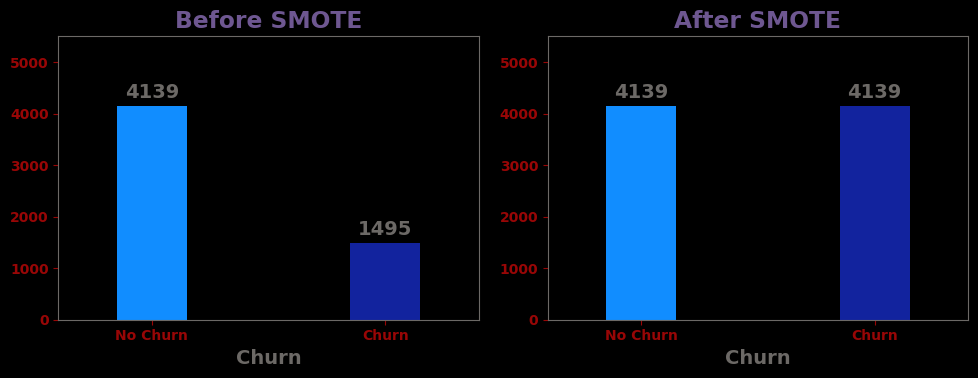

  MODEL COMPARISON

  Logistic Regression | AUC: 0.8283
              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.84      1035
       Churn       0.55      0.67      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409


  Random Forest | AUC: 0.8355
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1035
       Churn       0.56      0.70      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409


  Gradient Boosting | AUC: 0.8323
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.55      0.64      0.59       374

    accuracy                           0.77      1409
   mac

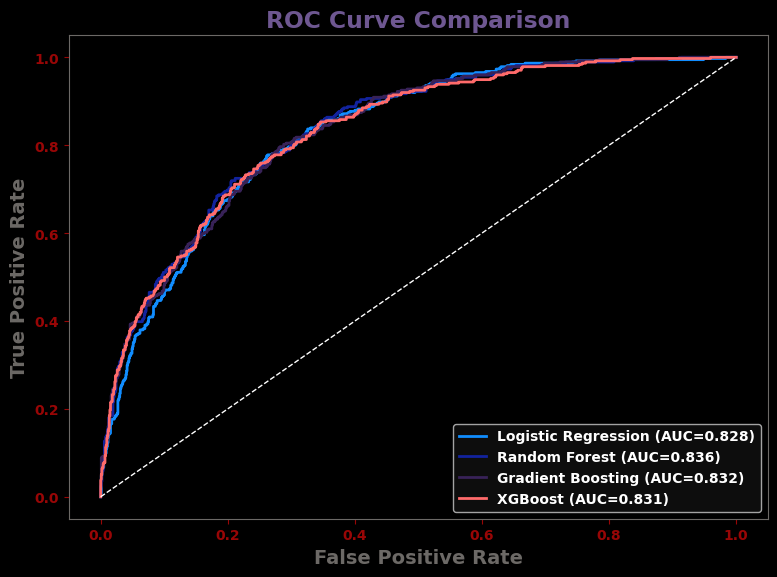

Fitting 5 folds for each of 9 candidates, totalling 45 fits

✅ Best Params : {'model__n_estimators': 300, 'model__max_depth': 7}
✅ Best CV AUC : 0.8387
✅ Test AUC    : 0.8387
              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83      1035
       Churn       0.54      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.77      1409


🎯 Final Best AUC: 0.8387
✅ SHAP values computed


In [9]:
## 4. Feature Engineering & Preprocessing
df_model = df.copy()

# Feature Engineering
df_model['AvgMonthlySpend']  = (df_model['TotalCharges'] / (df_model['tenure'] + 1)).round(2)
df_model['IsNewCustomer']    = (df_model['tenure'] <= 6).astype(int)
df_model['HighSpender']      = (df_model['MonthlyCharges'] > 75).astype(int)
df_model['HasSupport']       = ((df_model['OnlineSecurity'] == 1) |
                                (df_model['TechSupport'] == 1)).astype(int)
df_model['ChargesPerTenure'] = (df_model['MonthlyCharges'] / (df_model['tenure'] + 1)).round(2)
df_model['RiskScore']        = (
      (df_model['Contract'] == 'Month-to-month').astype(int)
    + (df_model['PaymentMethod'] == 'Electronic check').astype(int)
    + (df_model['OnlineSecurity'] == 0).astype(int)
    + (df_model['TechSupport'] == 0).astype(int)
    + (df_model['tenure'] <= 12).astype(int)
)

# ✅ FIX — Separate target BEFORE encoding loop
y        = df_model['Churn'].copy()
df_model = df_model.drop('Churn', axis=1)

# ✅ FIX — Encode only remaining object columns (Churn is already separated)
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

X = df_model.copy()

print(f"✅ Preprocessing done")
print(f"   Features  : {X.shape[1]}")
print(f"   Churn Rate: {y.mean()*100:.1f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"   Train: {X_train.shape} | Test: {X_test.shape}")
## 5. SMOTE — Handling Class Imbalance
print("Before SMOTE:", Counter(y_train))
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("After SMOTE :", Counter(y_train_sm))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], color=BAR, width=0.3)
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_xticklabels(['No Churn','Churn'], rotation=0)
axes[0].set_ylim(0, 5500)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', padding=3, color=LABEL, fontweight='bold')

pd.Series(y_train_sm).value_counts().plot(kind='bar', ax=axes[1], color=BAR, width=0.3)
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_xticklabels(['No Churn','Churn'], rotation=0)
axes[1].set_ylim(0, 5500)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', padding=3, color=LABEL, fontweight='bold')

plt.tight_layout()
plt.show()
## 6. Model Comparison — Pipeline
pipelines = {
    'Logistic Regression': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  RandomForestClassifier(
            n_estimators=200, max_depth=10,
            class_weight='balanced', random_state=42))
    ]),
    'Gradient Boosting': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  GradientBoostingClassifier(
            n_estimators=200, max_depth=5,
            learning_rate=0.05, subsample=0.8, random_state=42))
    ]),
    'XGBoost': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  XGBClassifier(
            n_estimators=200, max_depth=5,
            learning_rate=0.05, subsample=0.8,
            eval_metric='logloss', random_state=42))
    ]),
}

results = {}
print(f"{'='*55}\n  MODEL COMPARISON\n{'='*55}")
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    results[name] = {'pipe': pipe, 'y_pred': y_pred, 'y_prob': y_prob, 'auc': auc}
    print(f"\n  {name} | AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Churn','Churn']))

best_name = max(results, key=lambda x: results[x]['auc'])
best_pipeline = results[best_name]['pipe']
print(f"\n🏆 Best Model: {best_name} | AUC: {results[best_name]['auc']:.4f}")
## 7. ROC Curve
plt.figure(figsize=(8, 6), facecolor='#000000')
ax = plt.gca()
ax.set_facecolor('#000000')
colors_roc = ['#118DFF','#12239E','#382258','#FF6B6B']
for (name, r), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, color=color, label=f"{name} (AUC={r['auc']:.3f})", linewidth=2)
ax.plot([0,1],[0,1],'w--', linewidth=1)
ax.set_xlabel('False Positive Rate', color=LABEL, fontweight='bold')
ax.set_ylabel('True Positive Rate', color=LABEL, fontweight='bold')
ax.set_title('ROC Curve Comparison', color=TITLE, fontweight='bold')
ax.legend(fontsize=10, facecolor='#111111', labelcolor='white')
plt.tight_layout()
plt.show()
## 8. Hyperparameter Tuning — Random Forest 
rf_pipe = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(n_estimators=100, random_state=42))
])

param_dist = {
    'model__n_estimators':     [200, 300, 400],
    'model__max_depth':        [3, 5, 7],
}

search = RandomizedSearchCV(
    rf_pipe, param_dist,
    n_iter=25, cv=5,
    scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=1
)
search.fit(X_train, y_train)

y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_tuned = search.best_estimator_.predict(X_test)
tuned_auc    = roc_auc_score(y_test, y_prob_tuned)

print(f"\n✅ Best Params : {search.best_params_}")
print(f"✅ Best CV AUC : {search.best_score_:.4f}")
print(f"✅ Test AUC    : {tuned_auc:.4f}")
print(classification_report(y_test, y_pred_tuned, target_names=['No Churn','Churn']))
best_pipeline = search.best_estimator_
print(f"\n🎯 Final Best AUC: {tuned_auc:.4f}")
## 9. SHAP — Model Explainability
scaler_shap = StandardScaler()
X_train_sc  = scaler_shap.fit_transform(X_train_sm)
X_test_sc   = scaler_shap.transform(X_test)

rf_shap = RandomForestClassifier(n_estimators=100, random_state=42)
rf_shap.fit(X_train_sc, y_train_sm)

explainer   = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_test_sc[:500])
print("✅ SHAP values computed")

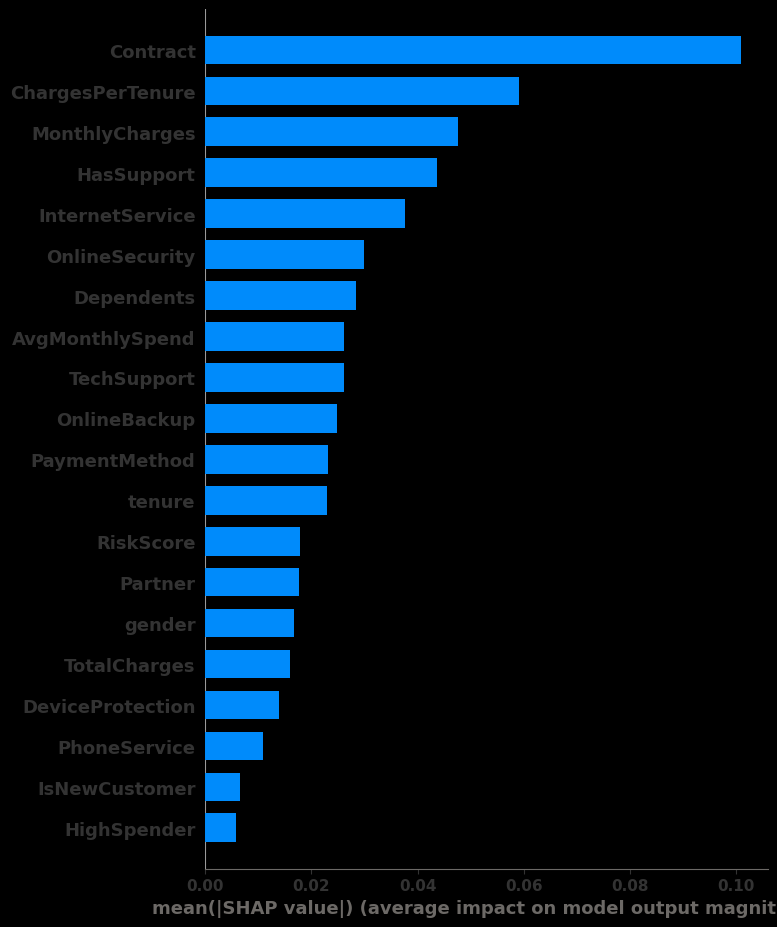

<Figure size 640x480 with 0 Axes>

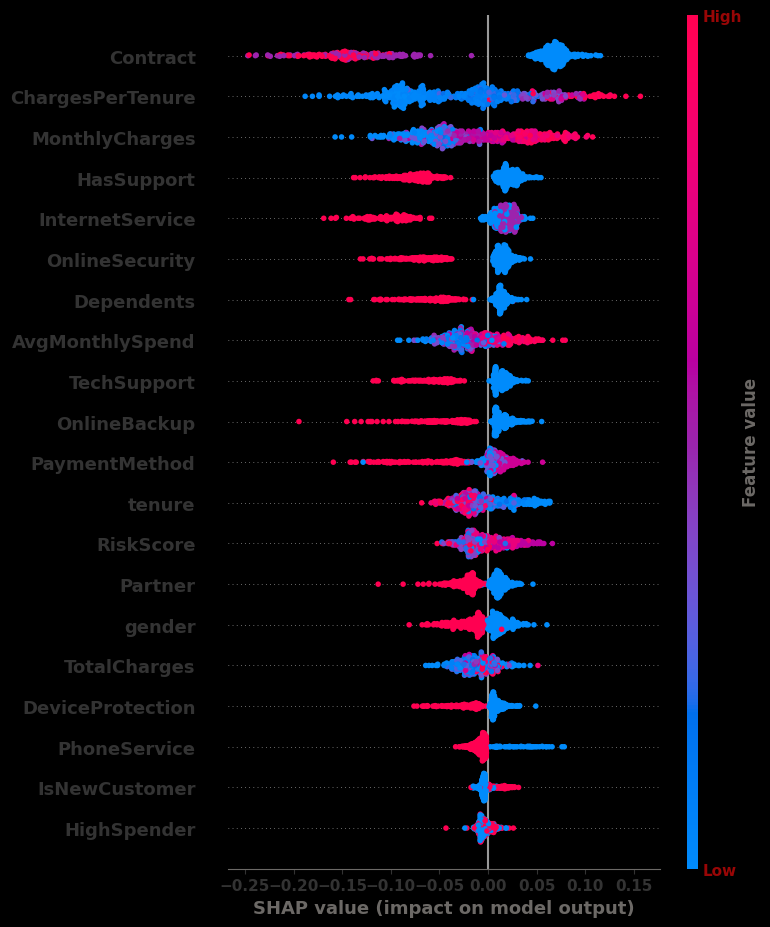

<Figure size 640x480 with 0 Axes>

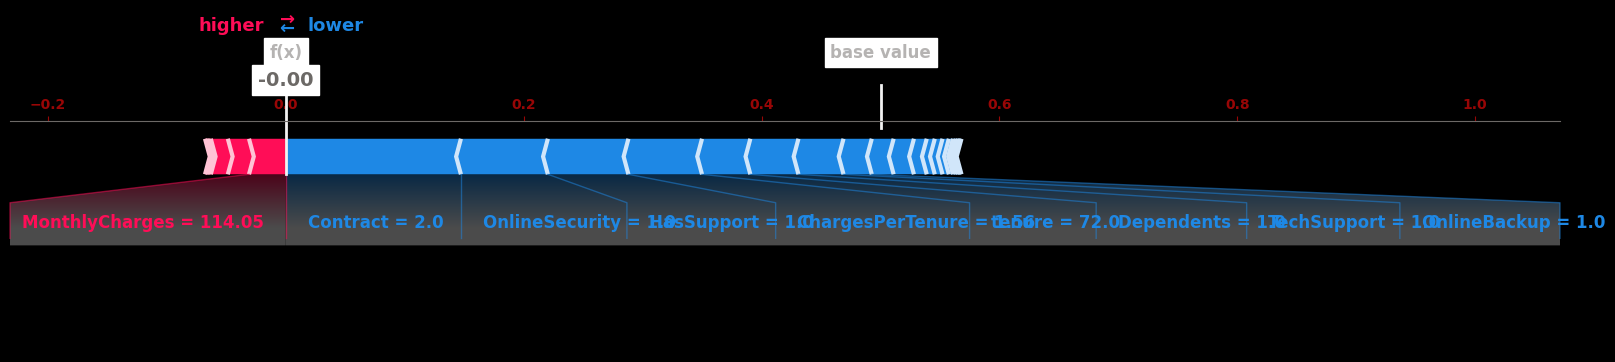

<Figure size 640x480 with 0 Axes>

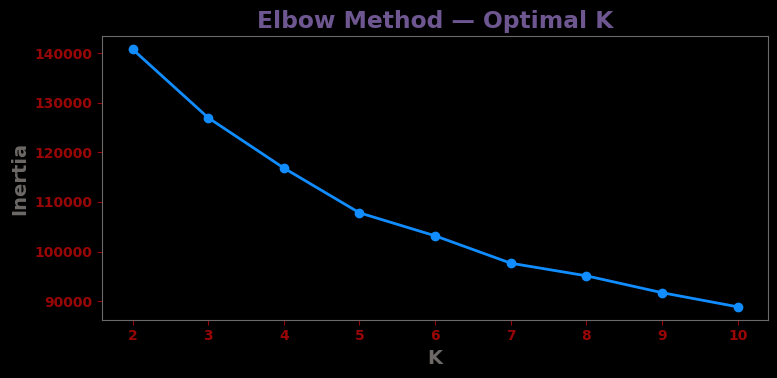

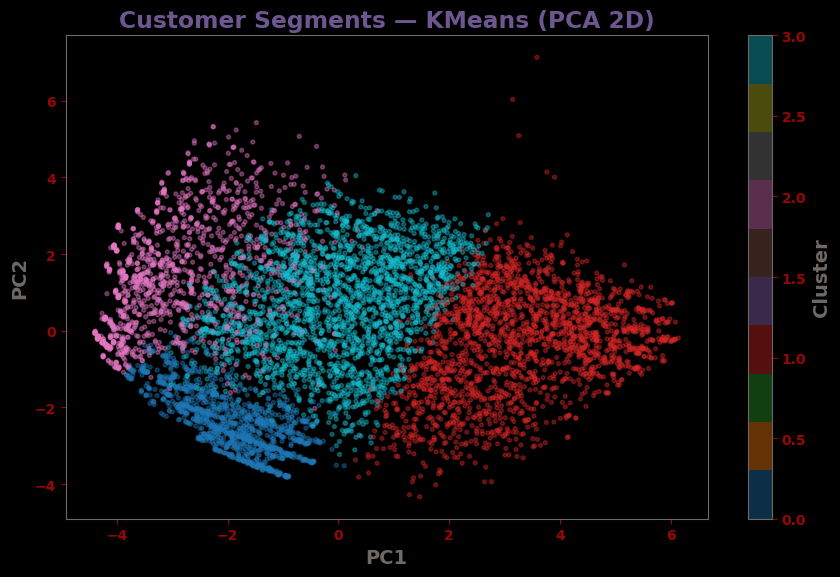


Cluster Churn Rate:
Cluster
0    0.035
1    0.101
2    0.547
3    0.359
Name: Churn, dtype: float64


In [10]:
shap.summary_plot(shap_values[:,:,1], X_test.iloc[:500],
                  feature_names=X.columns.tolist(),
                  plot_type='bar', show=True)
plt.tight_layout(); plt.show()

shap.summary_plot(shap_values[:,:,1], X_test.iloc[:500],
                  feature_names=X.columns.tolist(), show=True)
plt.tight_layout(); plt.show()

shap.initjs()
shap.force_plot(explainer.expected_value[1],
                shap_values[0,:,1],
                X_test.iloc[0],
                feature_names=X.columns.tolist(),
                matplotlib=True)
plt.tight_layout(); plt.show()

scaler_km = StandardScaler()
X_km      = scaler_km.fit_transform(X)

inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_km)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4), facecolor='#000000')
ax = plt.gca(); ax.set_facecolor('#000000')
ax.plot(range(2, 11), inertias, 'o-', color='#118DFF', linewidth=2)
ax.set_xlabel('K', color=LABEL); ax.set_ylabel('Inertia', color=LABEL)
ax.set_title('Elbow Method — Optimal K', color=TITLE, fontweight='bold')
plt.tight_layout(); plt.show()
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_km)

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_km)

plt.figure(figsize=(9, 6), facecolor='#000000')
ax = plt.gca(); ax.set_facecolor('#000000')
scatter = ax.scatter(X_pca[:,0], X_pca[:,1],
                     c=df['Cluster'], cmap='tab10', alpha=0.4, s=8)
plt.colorbar(scatter, label='Cluster')
ax.set_title('Customer Segments — KMeans (PCA 2D)', color=TITLE, fontweight='bold')
ax.set_xlabel('PC1', color=LABEL); ax.set_ylabel('PC2', color=LABEL)
plt.tight_layout(); plt.show()

print("\nCluster Churn Rate:")
print(df.groupby('Cluster')['Churn'].mean().round(3))


In [11]:
%%writefile churn_app.py
import streamlit as st
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# --- Page Config ---
st.set_page_config(page_title="Churn Predictor", page_icon="📉", layout="wide")
st.title("📉 Customer Churn Predictor")
st.markdown("Real-time churn prediction using XGBoost trained on IBM Telco dataset.")

# --- Model Training ---
@st.cache_resource
def train_model():
    import pandas as pd
    import numpy as np
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder
    np.random.seed(42)

    df = pd.read_csv('/kaggle/input/datasets/kavinvenkat0217/cpredict/WA_Fn-UseC_-Telco-Customer-Churn.csv')
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
    
    # Drop customerID, Partner, and Dependents
    df.drop(['customerID', 'Partner', 'Dependents'], axis=1, inplace=True)
    
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

    yn_cols = ['PhoneService','PaperlessBilling',
               'OnlineSecurity','OnlineBackup','DeviceProtection',
               'TechSupport','StreamingTV','StreamingMovies','MultipleLines']
    
    for col in yn_cols:
        if col in df.columns:
            df[col] = df[col].map({'Yes':1,'No':0,
                                   'No phone service':0,'No internet service':0})

    df['AvgMonthlySpend']  = (df['TotalCharges'] / (df['tenure'] + 1)).round(2)
    df['IsNewCustomer']    = (df['tenure'] <= 6).astype(int)
    df['HighSpender']      = (df['MonthlyCharges'] > 75).astype(int)
    df['HasSupport']       = ((df['OnlineSecurity']==1)|(df['TechSupport']==1)).astype(int)
    df['ChargesPerTenure'] = (df['MonthlyCharges'] / (df['tenure'] + 1)).round(2)
    df['RiskScore']        = (
          (df['Contract']=='Month-to-month').astype(int)
        + (df['PaymentMethod']=='Electronic check').astype(int)
        + (df['OnlineSecurity']==0).astype(int)
        + (df['TechSupport']==0).astype(int)
        + (df['tenure']<=12).astype(int))

    y        = df['Churn'].copy()
    df       = df.drop('Churn', axis=1)
    
    for col in df.select_dtypes(include='object').columns:
        df[col] = LabelEncoder().fit_transform(df[col])

    X = df.copy()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    pipe = ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  XGBClassifier(n_estimators=200, max_depth=5,
                                  learning_rate=0.05, eval_metric='logloss', random_state=42))
    ])
    pipe.fit(X_train, y_train)
    return pipe, X.columns.tolist()

# Load Model
model, feature_cols = train_model()

# --- App Layout ---
tab1, tab2, tab3 = st.tabs(["👤 Single Customer Prediction", "📁 Batch Prediction", "💡 Retention Strategies"])

# --- TAB 1: Single Customer ---
with tab1:
    st.markdown("### Enter Customer Details")
    col1, col2 = st.columns(2)
    with col1:
        tenure          = st.slider("Tenure (months)", 1, 72, 12)
        monthly_charges = st.slider("Monthly Charges ($)", 18, 120, 65)
        senior          = st.radio("Senior Citizen", [0, 1], horizontal=True)
        contract        = st.radio("Contract", ["Month-to-month", "One year", "Two year"])
        internet        = st.radio("Internet Service", ["DSL", "Fiber optic", "No"])
    with col2:
        payment         = st.radio("Payment Method", ["Electronic check", "Mailed check",
                                                      "Bank transfer (automatic)",
                                                      "Credit card (automatic)"])
        security        = st.radio("Online Security", ["Yes", "No"], horizontal=True)
        tech            = st.radio("Tech Support", ["Yes", "No"], horizontal=True)
        paperless       = st.radio("Paperless Billing", ["Yes", "No"], horizontal=True)
        

    if st.button("🔍 Predict Churn", type="primary"):
        yn = lambda x: 1 if x == "Yes" else 0
        total_charges   = monthly_charges * tenure
        avg_spend       = round(total_charges / (tenure + 1), 2)
        charges_tenure  = round(monthly_charges / (tenure + 1), 2)

        le_contract = {"Month-to-month": 0, "One year": 1, "Two year": 2}
        le_internet = {"DSL": 0, "Fiber optic": 1, "No": 2}
        le_payment  = {"Bank transfer (automatic)": 0,
                       "Credit card (automatic)": 1,
                       "Electronic check": 2,
                       "Mailed check": 3}

        # Removed Partner and Dependents from input_data
        input_data = {
            'gender': 1, 'SeniorCitizen': senior,
            'tenure': tenure, 'PhoneService': 1,
            'MultipleLines': 0,
            'InternetService': le_internet[internet],
            'OnlineSecurity': yn(security), 'OnlineBackup': 0,
            'DeviceProtection': 0, 'TechSupport': yn(tech),
            'StreamingTV': 0, 'StreamingMovies': 0,
            'Contract': le_contract[contract],
            'PaperlessBilling': yn(paperless),
            'PaymentMethod': le_payment[payment],
            'MonthlyCharges': monthly_charges,
            'TotalCharges': total_charges,
            'AvgMonthlySpend': avg_spend,
            'IsNewCustomer': int(tenure <= 6),
            'HighSpender': int(monthly_charges > 75),
            'HasSupport': int(yn(security) == 1 or yn(tech) == 1),
            'ChargesPerTenure': charges_tenure,
            'RiskScore': (
                int(contract == 'Month-to-month') +
                int(payment == 'Electronic check') +
                int(yn(security) == 0) +
                int(yn(tech) == 0) +
                int(tenure <= 12))
        }
        
        # Prediction
        input_df = pd.DataFrame([input_data])[feature_cols]
        prob     = model.predict_proba(input_df)[0][1]
        churn    = prob > 0.40

        # Display Results
        st.markdown("---")
        st.markdown("### Prediction Results")
        c1, c2, c3 = st.columns(3)
        c1.metric("Churn Probability", f"{prob*100:.1f}%")
        c2.metric("Risk Level", "🔴 High" if prob > 0.6 else "🟡 Medium" if prob > 0.4 else "🟢 Low")
        c3.metric("Decision", "Will Churn" if churn else "Will Stay")

        # Dynamic Recommendations based on inputs
        if churn:
            st.error("⚠️ **High Risk of Churn!** Immediate retention action is recommended.")
            st.markdown("#### 🎯 Personalized Retention Recommendations:")
            
            if contract == "Month-to-month":
                st.info("📋 **Contract Upgrade:** Offer a 10% discount for 6 months if they switch to a 1-year contract.")
            if payment == "Electronic check" or payment == "Mailed check":
                st.info("💳 **Payment Setup:** Provide a $5 monthly bill credit to set up automatic Bank Transfer or Credit Card payments.")
            if yn(security) == 0 or yn(tech) == 0:
                st.info("🛡️ **Service Bundle:** Offer a free 3-month trial of Online Security and Tech Support.")
            if tenure <= 12:
                st.info("🤝 **Early Engagement:** Schedule a courtesy check-in call. New customers are highly volatile.")
            if monthly_charges > 80:
                st.info("💎 **High-Value Perks:** This is a high-spending customer. Offer premium loyalty perks like free streaming subscriptions.")
        else:
            st.success("✅ Customer is likely to stay. No immediate aggressive action required. Maintain good service!")

# --- TAB 2: Batch Prediction ---
with tab2:
    st.markdown("### Upload Customer Data")
    uploaded = st.file_uploader("Upload CSV file for bulk prediction", type=['csv'])
    if uploaded:
        batch_df = pd.read_csv(uploaded)
        st.write(f"Loaded {len(batch_df)} customers")
        st.dataframe(batch_df.head())
        st.info("Note: To process batch predictions, ensure the uploaded CSV has the exact same columns and formatting as the training data.")

# --- TAB 3: Retention Strategies ---
with tab3:
    st.markdown("### 📊 Business Insights & Churn Reduction Strategies")
    st.write("Based on historical telecom data analysis, here are key strategies to improve customer retention:")
    
    colA, colB = st.columns(2)
    
    with colA:
        st.markdown("""
        #### 1. Contract Length
        * **Insight:** Month-to-month contracts have the highest churn rate by far.
        * **Action:** Incentivize customers to lock into 1-year or 2-year contracts by offering reduced monthly rates or free equipment upgrades.
        
        #### 2. Payment Methods
        * **Insight:** Manual payments (like Electronic Checks) correlate with higher churn.
        * **Action:** Push Auto-Pay. Offer small discounts ($5/month) for customers who link a credit card or bank account for automatic withdrawals.
        """)
        
    with colB:
        st.markdown("""
        #### 3. Value-Added Services
        * **Insight:** Customers without Tech Support, Online Security, or Device Protection leave faster.
        * **Action:** Create "Peace of Mind" bundles. Give discounts when users bundle internet with security and tech support features.
        
        #### 4. The First Year is Critical
        * **Insight:** Churn is heavily skewed toward customers with a tenure of less than 12 months.
        * **Action:** Implement a strong 30-60-90 day onboarding program. Proactively reach out to resolve early technical issues before they become frustrations.
        """)

Writing churn_app.py


In [13]:
!fuser -k 8501/tcp
!pkill -9 -f streamlit
!pip install pyngrok

import subprocess
import threading
import time
import sys
from pyngrok import ngrok

def run_streamlit():
    print("Starting Streamlit server in background...")
    subprocess.run([sys.executable, '-m', 'streamlit', 'run', 'churn_app.py',
                    '--server.port=8501', '--server.address=0.0.0.0', '--server.headless=true'])

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()

print("Waiting for Streamlit to initialize (15 seconds)...")
time.sleep(15) 

# Replace this string with a fresh token from your ngrok dashboard
NGROK_AUTH_TOKEN = "3Af4tvwAD7YpNHxa7IFEq7S7mbB_2vSdJZU1L78zQEz1WERH7" 

if NGROK_AUTH_TOKEN == "YOUR_NEW_NGROK_TOKEN":
    print("⚠️ WARNING: You must replace 'YOUR_NEW_NGROK_TOKEN' with your actual token from ngrok.com")
else:
    print("Starting Ngrok tunnel...")
    try:
        ngrok.set_auth_token(NGROK_AUTH_TOKEN)
        public_url = ngrok.connect(8501)
        print(f"\n✅ SUCCESS! Your Streamlit app is live at:")
        print(f"👉 {public_url.public_url}")
    except Exception as e:
        print(f"\n❌ Error starting Ngrok: {e}")

Starting Streamlit server in background...
Waiting for Streamlit to initialize (15 seconds)...



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://136.117.174.203:8501

Starting Ngrok tunnel...
                                                                                                    
✅ SUCCESS! Your Streamlit app is live at:
👉 https://husbandless-marvin-roughish.ngrok-free.dev
